# `nn.utils.weight_norm` 은 가중치를 어떻게 재매개화하는가?

$$
w_k \;=\; g_k\,\frac{v_k}{\lVert v_k\rVert}
$$

행렬 $W$ 의 각 행 $w_k$ 를 **크기 $g_k$(스칼라)** 와 **방향 $v_k/\lVert v_k\rVert$(단위벡터)** 로
분해해서, 둘을 **서로 다른 파라미터**로 학습한다.
이 스크립트는 그 사실을 하나씩 수치로 확인한다.

1. `weight_g` / `weight_v` 가 실제로 생기고 `weight` 가 둘로부터 계산됨
2. `weight_g.data.fill_(1)` → 모든 행의 노름이 정확히 1
3. 학습을 돌리면 $\lVert v_k\rVert$ 는 변해도 $\lVert w_k\rVert$ 는 $|g_k|$ 로 고정
4. $g$ 고정 vs 학습 → 로짓 범위 비교 (DINO가 고정하는 이유)
5. $\nabla_v L \perp v$ 를 2차원에서 수치 확인

In [1]:
# 필요 패키지: torch(2.4), plotly(6.9), kaleido, numpy
import os
import warnings

import torch
import torch.nn as nn
import torch.nn.functional as F
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# torch 2.4 에서 구 API 는 deprecation 경고를 낸다 (DINO 코드가 쓰는 그 API)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="torch.nn.utils.weight_norm")

torch.manual_seed(0)

OUT_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


print("torch", torch.__version__)

torch 2.4.0+cu121


## 1. `weight_norm` 을 씌우면 파라미터가 두 개로 갈라진다

`nn.Linear(4, 3, bias=False)` 의 원래 파라미터는 `weight` 하나 — shape `(3, 4)`.
여기에 `weight_norm` 을 씌우면

- `weight_g` : shape `(3, 1)` — 행마다 스칼라 $g_k$ 하나
- `weight_v` : shape `(3, 4)` — 행마다 방향 벡터 $v_k$

로 바뀌고, `weight` 는 더 이상 파라미터가 아니라 매 forward 마다 **계산되는 값**이 된다.

In [2]:
plain = nn.Linear(4, 3, bias=False)
W0 = plain.weight.detach().clone()

print("씌우기 전 파라미터:", [n for n, _ in plain.named_parameters()])

lin = nn.utils.weight_norm(plain)

print("씌운 후  파라미터:", [n for n, _ in lin.named_parameters()])
print("weight_g shape:", tuple(lin.weight_g.shape))
print("weight_v shape:", tuple(lin.weight_v.shape))
print("weight   shape:", tuple(lin.weight.shape), " (파라미터 아님, 파생값)")

print("\nweight_g (초기값) =", lin.weight_g.detach().flatten().tolist())
print("원래 W 각 행의 노름 =", W0.norm(dim=1).tolist())

print("\nweight_v == 원래 W ?", torch.allclose(lin.weight_v.detach(), W0))

씌우기 전 파라미터: ['weight']
씌운 후  파라미터: ['weight_g', 'weight_v']
weight_g shape: (3, 1)
weight_v shape: (3, 4)
weight   shape: (3, 4)  (파라미터 아님, 파생값)

weight_g (초기값) = [0.6137664914131165, 0.4607923924922943, 0.22796162962913513]
원래 W 각 행의 노름 = [0.6137664914131165, 0.4607923924922943, 0.22796162962913513]

weight_v == 원래 W ? True


초기 `weight_g[k]` 는 원래 행의 노름 $\lVert w_k\rVert$, `weight_v` 는 원래 $W$ 그대로다.
그래서 **재매개화 직후 층의 동작은 전혀 변하지 않는다**.

이제 $w_k = g_k\,v_k/\lVert v_k\rVert$ 가 실제로 성립하는지 손으로 계산해 대조한다.

In [3]:
g = lin.weight_g.detach()                     # (3, 1)
v = lin.weight_v.detach()                     # (3, 4)
w_manual = g * v / v.norm(dim=1, keepdim=True)  # 행별로 정규화 후 g 곱

_ = lin(torch.zeros(1, 4))                    # forward 훅이 lin.weight 를 갱신
w_actual = lin.weight.detach()

print("수동 계산 w:\n", w_manual)
print("\nPyTorch weight:\n", w_actual)
print("\n일치? ", torch.allclose(w_manual, w_actual, atol=1e-6))
print("최대 오차:", (w_manual - w_actual).abs().max().item())

수동 계산 w:
 tensor([[-0.0037,  0.2682, -0.4115, -0.3680],
        [-0.1926,  0.1341, -0.0099,  0.3964],
        [-0.0444,  0.1323, -0.1511, -0.0983]])

PyTorch weight:
 tensor([[-0.0037,  0.2682, -0.4115, -0.3680],
        [-0.1926,  0.1341, -0.0099,  0.3964],
        [-0.0444,  0.1323, -0.1511, -0.0983]])

일치?  True
최대 오차: 1.4901161193847656e-08


## 2. `weight_g.data.fill_(1)` — DINO 가 하는 일

$g_k = 1$ 로 채우면 $\lVert w_k\rVert = |g_k| = 1$. 모든 행이 **단위 벡터**가 된다.

In [4]:
lin.weight_g.data.fill_(1)
_ = lin(torch.zeros(1, 4))

print("g =", lin.weight_g.detach().flatten().tolist())
print("각 행 ||w_k|| =", lin.weight.detach().norm(dim=1).tolist())
print("각 행 ||v_k|| =", lin.weight_v.detach().norm(dim=1).tolist(), " <- v 는 여전히 제각각")

g = [1.0, 1.0, 1.0]
각 행 ||w_k|| = [1.0, 0.9999999403953552, 1.0]
각 행 ||v_k|| = [0.6137664914131165, 0.4607923924922943, 0.22796162962913513]  <- v 는 여전히 제각각


입력도 L2 정규화되어 있으면 ($\lVert \tilde u\rVert = 1$) 로짓은

$$
z_k = w_k^{\top}\tilde u = \lVert w_k\rVert\,\lVert\tilde u\rVert\cos\theta_k = \cos\angle(v_k, \tilde u) \in [-1, 1]
$$

즉 **프로토타입 방향과의 코사인 유사도**다. DINOHead 가 정확히 이 구조다.

In [5]:
u = F.normalize(torch.randn(8, 4), dim=-1)   # DINOHead 의 L2-normalized bottleneck
z = lin(u)
cos = F.normalize(lin.weight_v.detach(), dim=1) @ u.T  # cos(v_k, u) 직접 계산

print("로짓 범위: [%.4f, %.4f]" % (z.min().item(), z.max().item()))
print("로짓 == cos(v_k, u) ?", torch.allclose(z, cos.T, atol=1e-6))

로짓 범위: [-0.9142, 0.7771]
로짓 == cos(v_k, u) ? True


## 3. 학습해 보기 — $\lVert v_k\rVert$ 는 변해도 $\lVert w_k\rVert$ 는 $g$ 로 고정

작은 회귀 문제를 몇 스텝 학습하며 $\lVert v_k\rVert$, $\lVert w_k\rVert$, 로짓 범위를 기록한다.
`g_trainable=False` 가 DINO 설정(`weight_g.requires_grad = False`)이다.

In [6]:
def run(g_trainable, steps=300, lr=0.5, seed=0):
    torch.manual_seed(seed)
    layer = nn.utils.weight_norm(nn.Linear(4, 3, bias=False))
    layer.weight_g.data.fill_(1)
    layer.weight_g.requires_grad = g_trainable

    X = F.normalize(torch.randn(64, 4), dim=-1)
    target = torch.randn(64, 3) * 3.0          # 일부러 큰 스케일 -> g 를 키우고 싶어함
    opt = torch.optim.SGD([p for p in layer.parameters() if p.requires_grad], lr=lr)

    hist = {"vnorm": [], "wnorm": [], "g": [], "zmax": [], "loss": []}
    for _ in range(steps):
        out = layer(X)
        loss = F.mse_loss(out, target)
        opt.zero_grad(); loss.backward(); opt.step()
        with torch.no_grad():
            _ = layer(X[:1])                   # weight 갱신
            hist["vnorm"].append(layer.weight_v.norm(dim=1).tolist())
            hist["wnorm"].append(layer.weight.norm(dim=1).tolist())
            hist["g"].append(layer.weight_g.flatten().tolist())
            hist["zmax"].append(layer(X).abs().max().item())
            hist["loss"].append(loss.item())
    return layer, hist


layer_fix, h_fix = run(g_trainable=False)
layer_tr, h_tr = run(g_trainable=True)

print("[g 고정 (DINO)]")
print("  ||v_k||  처음:", ["%.4f" % x for x in h_fix["vnorm"][0]])
print("  ||v_k||  끝  :", ["%.4f" % x for x in h_fix["vnorm"][-1]], " <- 변했다")
print("  ||w_k||  처음:", ["%.4f" % x for x in h_fix["wnorm"][0]])
print("  ||w_k||  끝  :", ["%.4f" % x for x in h_fix["wnorm"][-1]], " <- 그대로 1")
print("  g        끝  :", ["%.4f" % x for x in h_fix["g"][-1]])

print("\n[g 학습]")
print("  ||w_k||  끝  :", ["%.4f" % x for x in h_tr["wnorm"][-1]], " <- 1을 벗어남")
print("  g        끝  :", ["%.4f" % x for x in h_tr["g"][-1]])

print("\n||w_k|| == |g_k| 항상 성립?",
      all(abs(a - abs(b)) < 1e-5
          for wr, gr in zip(h_tr["wnorm"], h_tr["g"]) for a, b in zip(wr, gr)))

[g 고정 (DINO)]
  ||v_k||  처음: ['0.6622', '0.4652', '0.7473']
  ||v_k||  끝  : ['0.7400', '0.4843', '0.7810']  <- 변했다
  ||w_k||  처음: ['1.0000', '1.0000', '1.0000']
  ||w_k||  끝  : ['1.0000', '1.0000', '1.0000']  <- 그대로 1
  g        끝  : ['1.0000', '1.0000', '1.0000']

[g 학습]
  ||w_k||  끝  : ['1.8609', '0.3687', '2.0040']  <- 1을 벗어남
  g        끝  : ['1.8609', '0.3687', '2.0040']

||w_k|| == |g_k| 항상 성립? True


**$v$ 의 노름은 학습 중 계속 자라지만 $w$ 에는 아무 영향이 없다.**
$w$ 의 크기는 오직 $g$ 가 정한다 — 이것이 "크기와 방향의 분리"의 실체다.

## 4. 로짓 범위 비교: $g$ 고정 vs 학습

In [7]:
print("입력이 단위벡터일 때 |z| 최댓값")
print("  g 고정 : 처음 %.4f  ->  끝 %.4f   (구조적으로 <= 1)" % (h_fix["zmax"][0], h_fix["zmax"][-1]))
print("  g 학습 : 처음 %.4f  ->  끝 %.4f   (상한 없음)" % (h_tr["zmax"][0], h_tr["zmax"][-1]))
print("\n  최종 loss   g고정 %.4f / g학습 %.4f" % (h_fix["loss"][-1], h_tr["loss"][-1]))

입력이 단위벡터일 때 |z| 최댓값
  g 고정 : 처음 0.9688  ->  끝 0.9640   (구조적으로 <= 1)
  g 학습 : 처음 0.8860  ->  끝 1.9295   (상한 없음)

  최종 loss   g고정 11.0118 / g학습 10.8352


$g$ 를 풀어주면 loss 는 조금 더 내려가지만 로짓 스케일이 자유롭게 커진다.
DINO 는 softmax 를 $z/\tau$ 로 먹이므로, 로짓 스케일이 자라면 특정 프로토타입이
분포를 독식하는 **붕괴(collapse)** 로 갈 수 있다. 그래서 $g_k \equiv 1$ 로 얼려
"누가 더 큰가" 대신 **"누가 방향이 더 맞는가"** 만 겨루게 만든다.

## 5. $\nabla_v L \perp v$ — 2차원에서 확인

$$
\nabla_{v}L = \frac{g}{\lVert v\rVert}\Big(I - \hat v\hat v^{\top}\Big)\nabla_{w}L,
\qquad \hat v = \frac{v}{\lVert v\rVert}
$$

괄호 안은 "$\hat v$ 방향 성분을 빼고 수직 성분만 남기는" 연산이므로 결과는 항상 $v$ 에 수직이다.

In [8]:
torch.manual_seed(30)
lin2 = nn.utils.weight_norm(nn.Linear(2, 1, bias=False))
lin2.weight_g.data.fill_(1.3)

x2 = F.normalize(torch.randn(16, 2), dim=-1)
y2 = torch.randn(16, 1) * 0.8 + 0.9 * (x2 @ torch.tensor([[1.0], [-0.6]]))

loss2 = F.mse_loss(lin2(x2), y2)
loss2.backward()

v2 = lin2.weight_v.detach()[0]        # (2,)
gv = lin2.weight_v.grad[0]            # (2,)
gg = lin2.weight_g.grad.item()
g2 = lin2.weight_g.detach().item()
vhat = v2 / v2.norm()

print("v      =", [round(t, 4) for t in v2.tolist()])
print("grad_v =", [round(t, 4) for t in gv.tolist()])
print("v · grad_v = %.3e   (0 이면 수직)" % torch.dot(v2, gv).item())
print("사잇각 = %.4f deg" % torch.rad2deg(torch.acos(
    torch.dot(vhat, gv / gv.norm()).clamp(-1, 1))).item())

v      = [0.5667, 0.3484]
grad_v = [-1.5022, 2.4435]
v · grad_v = -1.192e-07   (0 이면 수직)
사잇각 = 90.0000 deg


이제 같은 층을 **재매개화 없이** 만들어 $\nabla_w L$ 를 구하고,
위 공식으로 $\nabla_v L$, $\partial L/\partial g$ 를 손으로 재현해 본다.

In [9]:
w2 = (g2 * vhat).detach().clone().unsqueeze(0)        # w = g * vhat
w2.requires_grad_(True)
F.mse_loss(x2 @ w2.T, y2).backward()
gw = w2.grad[0]                                       # grad_w L

I = torch.eye(2)
gv_manual = (g2 / v2.norm()) * (I - torch.outer(vhat, vhat)) @ gw
gg_manual = torch.dot(vhat, gw).item()

print("grad_w        =", [round(t, 4) for t in gw.tolist()])
print("grad_v (공식) =", [round(t, 4) for t in gv_manual.tolist()])
print("grad_v (torch)=", [round(t, 4) for t in gv.tolist()])
print("일치?", torch.allclose(gv_manual, gv, atol=1e-5))
print("\ndL/dg (공식) = %.6f   (torch) = %.6f  <- gradient 의 v 방향(나란한) 성분"
      % (gg_manual, gg))

grad_w        = [-0.1819, 1.6112]
grad_v (공식) = [-1.5022, 2.4435]
grad_v (torch)= [-1.5022, 2.4435]
일치? True

dL/dg (공식) = 0.688851   (torch) = 0.688851  <- gradient 의 v 방향(나란한) 성분


**gradient 가 정확히 두 조각으로 나뉜다.**

- $\hat v$ 와 **나란한** 성분 $\to$ $\dfrac{\partial L}{\partial g}$ (크기를 고친다)
- $\hat v$ 와 **수직인** 성분 $\to$ $\nabla_v L$ (방향만 돌린다)

아래에서 $\nabla_w L$ 를 이 두 조각으로 실제로 분해해 확인한다.

In [10]:
par = gg_manual * vhat                 # 나란한 성분
perp = gw - par                        # 수직 성분
print("grad_w = 나란한 성분 + 수직 성분")
print("  나란한 :", [round(t, 4) for t in par.tolist()], " (크기 %.4f = |dL/dg|)" % par.norm())
print("  수직   :", [round(t, 4) for t in perp.tolist()])
print("  재조립 == grad_w ?", torch.allclose(par + perp, gw, atol=1e-6))
print("  수직 성분 * g/||v|| == grad_v ?",
      torch.allclose(perp * (g2 / v2.norm()), gv, atol=1e-5))

grad_w = 나란한 성분 + 수직 성분
  나란한 : [0.5868, 0.3608]  (크기 0.6889 = |dL/dg|)
  수직   : [-0.7687, 1.2504]
  재조립 == grad_w ? True
  수직 성분 * g/||v|| == grad_v ? True


## 6. 그림으로 보기

- **왼쪽**: 2차원에서 $v$, 단위 방향 $\hat v$, $w = g\hat v$, 그리고 $\nabla_w L$ 의
  나란한/수직 분해와 $\nabla_v L$ 의 수직성
- **가운데**: 학습 중 $\lVert v_k\rVert$(증가) vs $\lVert w_k\rVert$(불변).
  행마다 절대 스케일이 달라서 **초기값 대비 배율**로 그렸다 —
  $w$ 곡선 세 개는 정확히 1에 붙어 겹치고, $v$ 곡선만 위로 올라간다.
- **오른쪽**: $g$ 고정 vs 학습일 때 로짓 절댓값 최댓값 추이

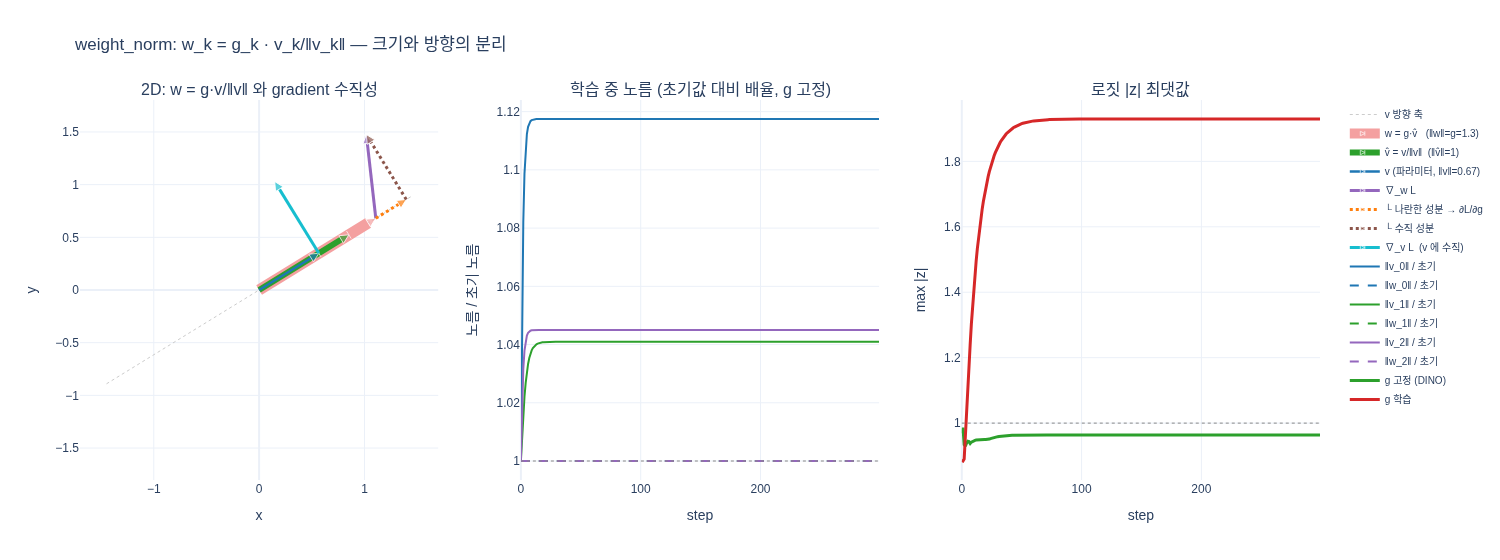

saved: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/857483e1-377b-465e-a8c1-af9184906bf6/expy.png


In [11]:
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("2D: w = g·v/‖v‖ 와 gradient 수직성",
                    "학습 중 노름 (초기값 대비 배율, g 고정)",
                    "로짓 |z| 최댓값"),
)


def arrow(vec, name, color, dash=None, origin=(0.0, 0.0), width=3):
    return go.Scatter(
        x=[origin[0], origin[0] + vec[0]], y=[origin[1], origin[1] + vec[1]],
        mode="lines+markers", name=name,
        line=dict(color=color, width=width, dash=dash),
        marker=dict(size=[0, 9], symbol="arrow-bar-up",
                    angleref="previous", color=color),
    )


vvec = tuple(v2.tolist())
hvec = tuple(vhat.tolist())
wvec = tuple((g2 * vhat).tolist())
S = 0.8 / gw.norm().item()                 # gradient 들을 보기 좋은 길이로 공통 축소
gwv = tuple((gw * S).tolist())
parv = tuple((par * S).tolist())
perpv = tuple((perp * S).tolist())
gvv = tuple((gv / gv.norm() * 0.8).tolist())   # ∇_v L 은 방향만 보면 된다

# v 방향 기준축 (점선)
fig.add_trace(go.Scatter(x=[-1.7 * hvec[0], 1.7 * hvec[0]], y=[-1.7 * hvec[1], 1.7 * hvec[1]],
                         mode="lines", name="v 방향 축",
                         line=dict(color="#cccccc", width=1, dash="dot")), row=1, col=1)

# v, v̂, w 는 모두 같은 직선 위에 있다 -> 굵기를 달리해 겹쳐 보이게 그린다
fig.add_trace(arrow(wvec, f"w = g·v̂   (‖w‖=g={g2:.1f})", "#f4a0a0", width=11), row=1, col=1)
fig.add_trace(arrow(hvec, "v̂ = v/‖v‖  (‖v̂‖=1)", "#2ca02c", width=6), row=1, col=1)
fig.add_trace(arrow(vvec, f"v (파라미터, ‖v‖={v2.norm():.2f})", "#1f77b4", width=2.5), row=1, col=1)

# gradient 분해는 w 의 끝점에서 출발시킨다 (겹침 방지)
tip = wvec
fig.add_trace(arrow(gwv, "∇_w L", "#9467bd", origin=tip), row=1, col=1)
fig.add_trace(arrow(parv, "└ 나란한 성분 → ∂L/∂g", "#ff7f0e", dash="dot", origin=tip), row=1, col=1)
fig.add_trace(arrow(perpv, "└ 수직 성분", "#8c564b", dash="dot",
                    origin=(tip[0] + parv[0], tip[1] + parv[1])), row=1, col=1)

# ∇_v L 은 v 의 끝점에서 — v 에 수직임이 한눈에 보인다
fig.add_trace(arrow(gvv, "∇_v L  (v 에 수직)", "#17becf", origin=vvec), row=1, col=1)

# 행마다 스케일이 달라 절대값은 겹쳐 보이지 않는다 -> 초기값 대비 배율로 그린다
steps = list(range(len(h_fix["vnorm"])))
palette = ["#1f77b4", "#2ca02c", "#9467bd"]
v0 = h_fix["vnorm"][0]
w0 = h_fix["wnorm"][0]
for k in range(3):
    fig.add_trace(go.Scatter(x=steps, y=[r[k] / v0[k] for r in h_fix["vnorm"]],
                             mode="lines", name=f"‖v_{k}‖ / 초기",
                             line=dict(color=palette[k], width=2)), row=1, col=2)
    fig.add_trace(go.Scatter(x=steps, y=[r[k] / w0[k] for r in h_fix["wnorm"]],
                             mode="lines", name=f"‖w_{k}‖ / 초기",
                             line=dict(color=palette[k], width=2, dash="dash")), row=1, col=2)
fig.add_hline(y=1.0, line=dict(color="#888888", width=1, dash="dot"), row=1, col=2)

fig.add_trace(go.Scatter(x=steps, y=h_fix["zmax"], mode="lines",
                         name="g 고정 (DINO)", line=dict(color="#2ca02c", width=3)), row=1, col=3)
fig.add_trace(go.Scatter(x=steps, y=h_tr["zmax"], mode="lines",
                         name="g 학습", line=dict(color="#d62728", width=3)), row=1, col=3)
fig.add_hline(y=1.0, line=dict(color="#888888", width=1, dash="dot"), row=1, col=3)

fig.update_xaxes(title_text="x", range=[-1.7, 1.7], row=1, col=1)
fig.update_yaxes(title_text="y", range=[-1.7, 1.7], scaleanchor="x", scaleratio=1, row=1, col=1)
fig.update_xaxes(title_text="step", row=1, col=2)
fig.update_yaxes(title_text="노름 / 초기 노름", row=1, col=2)
fig.update_xaxes(title_text="step", row=1, col=3)
fig.update_yaxes(title_text="max |z|", row=1, col=3)
fig.update_layout(
    title="weight_norm: w_k = g_k · v_k/‖v_k‖ — 크기와 방향의 분리",
    width=1500, height=560, template="plotly_white",
    legend=dict(font=dict(size=10)),
)

_show(fig)

png_path = os.path.join(OUT_DIR, "expy.png")
fig.write_image(png_path, scale=2)
print("saved:", png_path)

## 정리

| 확인한 것 | 결과 |
|---|---|
| `weight_norm` 후 파라미터 | `weight_g` `(K,1)` + `weight_v` `(K,n)`, `weight` 는 파생값 |
| $w_k = g_k v_k/\lVert v_k\rVert$ | 수동 계산과 `lin.weight` 완전 일치 |
| `weight_g.fill_(1)` | 모든 행 $\lVert w_k\rVert = 1$ → 로짓 = 코사인 유사도 ∈ $[-1,1]$ |
| 학습 중 | $\lVert v_k\rVert$ 는 자라도 $\lVert w_k\rVert = |g_k|$ 로 불변 |
| $g$ 학습 허용 | 로짓 최댓값이 1을 넘어 자유롭게 커짐 (DINO 가 막는 것) |
| gradient | $\nabla_v L \perp v$ (사잇각 정확히 90°), 나란한 성분은 $\partial L/\partial g$ 로 |